# **Mount Ke Google Drive**

In [ ]:
import os
from google.colab import drive

# Mount drive dulu kalau belum
drive.mount('/content/drive')

# Path menuju folder Colab Notebooks (perhatikan spasinya)
path_colab = '/content/drive/MyDrive/Colab Notebooks/Image Papaya'

# Buat folder jika belum ada
if not os.path.exists(path_colab):
    os.makedirs(path_colab)
    print("Folder berhasil dibuat di Colab Notebooks!")
else:
    print("Folder sudah tersedia.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder sudah tersedia.


# **Library**

In [ ]:
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
import matplotlib.pyplot as plt

# **Proses**

In [ ]:
data = []
# loop untuk setiap file citra di folder
for file_name in os.listdir(path_colab):
    if file_name.endswith('.jpg') or file_name.endswith('.jpeg') or file_name.endswith('.png') or file_name.endswith('.bmp'):
        row_data = []
        file_path = os.path.join(path_colab, file_name)
        row_data.append(file_name)

        # preprocessing gambar
        src = cv2.imread(file_path)
        rs = cv2.resize(src, (300, 300))
        gray = cv2.cvtColor(rs, cv2.COLOR_BGR2GRAY)
        hsv = cv2.cvtColor(src, cv2.COLOR_BGR2HSV)
        h, s, v = cv2.split(hsv)

        # ekstraksi properti warna
        hue_mean = np.mean(h)
        saturation_mean = np.mean(s)
        value_mean = np.mean(v)
        hue_std = np.std(h)
        saturation_std = np.std(s)
        value_std = np.std(v)

        # ekstraksi properti bentuk
        contours, hierarchy = cv2.findContours(cv2.Canny(src, 100, 200), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        cnt = max(contours, key=cv2.contourArea)
        perimeter = cv2.arcLength(cnt, True)
        area = cv2.contourArea(cnt)
        circularity = 4 * np.pi * (area / perimeter ** 2)
        aspect_ratio = float(src.shape[0]) / src.shape[1]
        extent = area / (src.shape[0] * src.shape[1])
        solidity = area / cv2.contourArea(cv2.convexHull(cnt))

        
        # Membentuk matriks hubungan antar piksel abu-abu
        g = graycomatrix(gray, distances=[1], angles=[0], symmetric=True, normed=True)
        # Digunakan sebagai perbedaan piksel besar
        contrast = graycoprops(g, 'contrast')[0][0]
        # tambahkan ke data
        row_data.extend([contrast])
        data.append(row_data)

#**Output**

In [ ]:
#Nama Kolom yang akan di tampilkan (Fokus di Tekstur)
tabel = ['File Name', 'texture_contrast']
#Mengambil dari data perhitungan
df = pd.DataFrame(data, columns=tabel)

# export ke file Excel
file_path = os.path.join(path_colab, 'Dani2418015Ekstrasi Daun Pepaya.xlsx')
# Output File Ke Excel
df.to_excel(file_path, index=False)
# Output Tabel
df

,File Name,texture_contrast
0,100.jpg,51.820145
1,4.jpg,47.207715
2,96.jpg,45.202910
3,3.jpg,41.241628
4,94.jpg,78.389777
5,2.jpg,84.068216
6,97.jpg,45.184036
7,99.jpg,54.248071
8,5.jpg,106.597848
9,1.jpg,78.432731


# **Histogram**

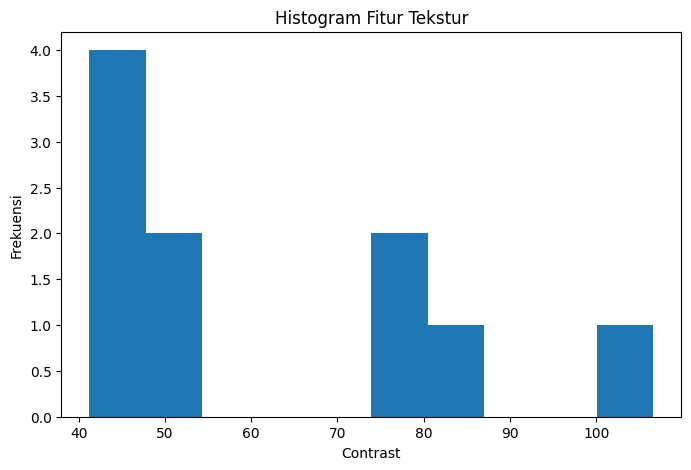

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['texture_contrast'], bins=10)

plt.xlabel('Contrast')
plt.ylabel('Frekuensi')
plt.title('Histogram Fitur Tekstur')
plt.show()